calculate FF MSA monthly mean

In [ ]:
# # Decompress the SIF files
# import gzip
# import shutil

# for year in range(2001, 2016):
#     for month in range(1, 13):
#         SIF_file = f'../gis/SIF/GOSIF_{year:04d}.M{month:02d}.tif.gz'
#         decompressed_file = SIF_file.replace('.gz', '')
#         with gzip.open(SIF_file, 'rb') as f_in:
#             with open(decompressed_file, 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

In [4]:
from constants import MSA_FILE
import gzip
import shutil
import os
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import constants

In [ ]:
# read shapefile and unit crs
msa_gdf_crsaea = gpd.read_file(constants.MSA_FILE)
msa_gdf_crs4326 = msa_gdf_crsaea.to_crs(epsg=4326) #odiac is in wgs84 (epsg 4326)

In [16]:
ff_monthly_mean_dict

{'Sioux Falls, SD-MN Metro Area': [np.float32(7.6120133)],
 'Wichita Falls, TX Metro Area': [np.float32(4.7472677)],
 'College Station-Bryan, TX Metro Area': [np.float32(49.666843)],
 'Grand Forks, ND-MN Metro Area': [np.float32(6.219143)],
 'Sebring, FL Metro Area': [np.float32(5.216013)],
 'Toledo, OH Metro Area': [np.float32(54.65714)],
 'Bismarck, ND Metro Area': [np.float32(11.316888)],
 'Eagle Pass, TX Metro Area': [np.float32(1.9955963)],
 'Clarksville, TN-KY Metro Area': [np.float32(54.61175)],
 'Owensboro, KY Metro Area': [np.float32(36.10745)],
 'Fayetteville-Springdale-Rogers, AR Metro Area': [np.float32(19.698439)],
 'Panama City-Panama City Beach, FL Metro Area': [np.float32(26.950933)],
 'Bellingham, WA Metro Area': [np.float32(4.0054865)],
 'Billings, MT Metro Area': [np.float32(4.0443616)],
 'Lake Havasu City-Kingman, AZ Metro Area': [np.float32(1.6537663)],
 'Chico, CA Metro Area': [np.float32(4.748422)],
 'Houma-Bayou Cane-Thibodaux, LA Metro Area': [np.float32(6.4982

In [ ]:
import geopandas as gpd
import numpy as np
import rioxarray
import pandas as pd
import rasterio.features
from utils import get_masked_raster

ff_monthly_mean = []
monthly_ff = r'c:\Users\qifanw\Documents\gis\fossil_fuel\2002\odiac2022_1km_excl_intl_0201.tif\odiac2022_1km_excl_intl_0201.tif'

raster_ds = rioxarray.open_rasterio(monthly_ff)
raster_data = raster_ds.values[0]

for _, row in msa_gdf_crs4326.iterrows():
    print(row['NAMELSAD'])
    row_gdf = msa_gdf_crs4326.loc[[row.name]] # Create a one-row GeoDataFrame instead of filtering
    masked_raster = get_masked_raster(row_gdf, raster_data, raster_ds.rio.transform())
    mean_value = np.nanmean(masked_raster)
    ff_monthly_mean.append(mean_value)

   

Sioux Falls, SD-MN Metro Area
Wichita Falls, TX Metro Area
College Station-Bryan, TX Metro Area
Grand Forks, ND-MN Metro Area
Sebring, FL Metro Area
Toledo, OH Metro Area
Bismarck, ND Metro Area
Eagle Pass, TX Metro Area
Clarksville, TN-KY Metro Area
Owensboro, KY Metro Area
Fayetteville-Springdale-Rogers, AR Metro Area
Panama City-Panama City Beach, FL Metro Area
Bellingham, WA Metro Area
Billings, MT Metro Area
Lake Havasu City-Kingman, AZ Metro Area
Chico, CA Metro Area
Houma-Bayou Cane-Thibodaux, LA Metro Area
Pocatello, ID Metro Area
Grand Junction, CO Metro Area
Gadsden, AL Metro Area
San Luis Obispo-Paso Robles, CA Metro Area
Great Falls, MT Metro Area
Scranton--Wilkes-Barre, PA Metro Area
Beckley, WV Metro Area
Flagstaff, AZ Metro Area
Pensacola-Ferry Pass-Brent, FL Metro Area
Wenatchee-East Wenatchee, WA Metro Area
Binghamton, NY Metro Area
Jacksonville, NC Metro Area
Visalia, CA Metro Area
Ocala, FL Metro Area
El Centro, CA Metro Area
Beaumont-Port Arthur, TX Metro Area
Tampa

In [25]:
 # Create a pandas DataFrame from ff_monthly_mean
ff_monthly_mean_df = pd.DataFrame({
    'NAMELSAD': msa_gdf_crs4326['NAMELSAD'],
    'ff_200201': ff_monthly_mean
})
ff_monthly_mean_df.to_csv(r'c:\Users\qifanw\Documents\test\test_ff_200201.csv', index=False)

In [27]:
test = pd.read_csv(r'c:\Users\qifanw\Documents\test\test_ff_200201.csv')

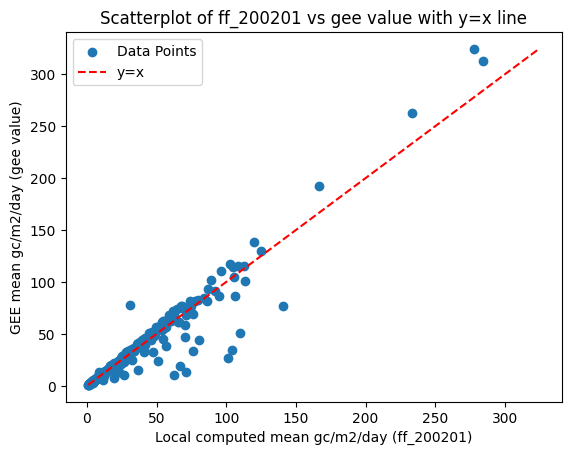

In [37]:
import numpy as np

import matplotlib.pyplot as plt

# Ensure x and y are the same length and unit
x = test['ff_200201']
y = test['gee value']

# Create a scatter plot
plt.scatter(x, y, label='Data Points')

# Add a y=x line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='y=x')

# Add labels, title, and legend
plt.xlabel('Local computed mean gc/m2/day (ff_200201)')
plt.ylabel('GEE mean gc/m2/day (gee value)')
plt.title('Scatterplot of ff_200201 vs gee value with y=x line')
plt.legend()
plt.show()

In [32]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
import rioxarray

# Define the precise masking and mean function
def get_masked_mean(gdf, raster_path):
    '''
    Mask the raster with a polygon (keeping pixels partially overlapped).
    Return the nanmean of the raster values inside the polygon.
    '''
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(
            src,
            gdf.geometry,
            crop=False,        # Do not crop: just mask
            filled=True,       # Fill masked values
            nodata=np.nan      # Set nodata as np.nan
        )
    
    masked_raster = out_image[0]  # Single-band raster

    # Calculate mean, ignoring NaN
    mean_val = np.nanmean(masked_raster)
    return mean_val

# Load your raster
monthly_ff = r'c:\Users\qifanw\Documents\gis\fossil_fuel\2002\odiac2022_1km_excl_intl_0201.tif\odiac2022_1km_excl_intl_0201.tif'
raster_ds = rioxarray.open_rasterio(monthly_ff)

# Assume raster has only 1 band
raster_path = monthly_ff

# Load your MSA GeoDataFrame (already in CRS matching raster)
# msa_gdf_crs4326 = gpd.read_file(...)

ff_monthly_mean = []

# Loop through each MSA
for _, row in msa_gdf_crs4326.iterrows():
    print(row['NAMELSAD'])
    
    # Create single-row GeoDataFrame
    row_gdf = msa_gdf_crs4326.loc[[row.name]]
    
    # Get masked raster
    mean_value = get_masked_mean(row_gdf, raster_path)
    ff_monthly_mean.append(mean_value)



ff_monthly_mean_df1 = pd.DataFrame({
    'NAMELSAD': msa_gdf_crs4326['NAMELSAD'],
    'ff_200201': ff_monthly_mean
})

Sioux Falls, SD-MN Metro Area
Wichita Falls, TX Metro Area
College Station-Bryan, TX Metro Area
Grand Forks, ND-MN Metro Area
Sebring, FL Metro Area
Toledo, OH Metro Area
Bismarck, ND Metro Area
Eagle Pass, TX Metro Area
Clarksville, TN-KY Metro Area
Owensboro, KY Metro Area
Fayetteville-Springdale-Rogers, AR Metro Area
Panama City-Panama City Beach, FL Metro Area
Bellingham, WA Metro Area
Billings, MT Metro Area
Lake Havasu City-Kingman, AZ Metro Area
Chico, CA Metro Area
Houma-Bayou Cane-Thibodaux, LA Metro Area
Pocatello, ID Metro Area
Grand Junction, CO Metro Area
Gadsden, AL Metro Area
San Luis Obispo-Paso Robles, CA Metro Area
Great Falls, MT Metro Area
Scranton--Wilkes-Barre, PA Metro Area
Beckley, WV Metro Area
Flagstaff, AZ Metro Area
Pensacola-Ferry Pass-Brent, FL Metro Area
Wenatchee-East Wenatchee, WA Metro Area
Binghamton, NY Metro Area
Jacksonville, NC Metro Area
Visalia, CA Metro Area
Ocala, FL Metro Area
El Centro, CA Metro Area
Beaumont-Port Arthur, TX Metro Area
Tampa

In [35]:
ff_monthly_mean

[np.float32(7.6120133),
 np.float32(4.7472677),
 np.float32(49.666843),
 np.float32(6.219143),
 np.float32(5.216013),
 np.float32(54.65714),
 np.float32(11.316888),
 np.float32(1.9955963),
 np.float32(54.61175),
 np.float32(36.10745),
 np.float32(19.698439),
 np.float32(26.950933),
 np.float32(4.0054865),
 np.float32(4.0443616),
 np.float32(1.6537663),
 np.float32(4.748422),
 np.float32(6.498287),
 np.float32(4.1621823),
 np.float32(3.2753346),
 np.float32(17.015816),
 np.float32(3.5006196),
 np.float32(3.0995708),
 np.float32(21.0816),
 np.float32(7.331852),
 np.float32(7.2177215),
 np.float32(40.852413),
 np.float32(1.493644),
 np.float32(13.981832),
 np.float32(12.405608),
 np.float32(3.653354),
 np.float32(12.422448),
 np.float32(4.488828),
 np.float32(46.551838),
 np.float32(125.16763),
 np.float32(7.2458863),
 np.float32(0.9834356),
 np.float32(6.786107),
 np.float32(3.2935243),
 np.float32(61.76942),
 np.float32(1.062266),
 np.float32(17.451056),
 np.float32(7.913537),
 np.float

In [34]:
ff_monthly_mean_df1.to_csv(r'c:\Users\qifanw\Documents\test\test_ff_200201_new.csv', index=False)

In [ ]:
from utils import get_masked_raster

temp_tif = r'c:\Users\qifanw\Documents\gis\fossil_fuel\2002\odiac2022_1km_excl_intl_0201.tif\odiac2022_1km_excl_intl_0201.tif'
with rasterio.open(temp_tif) as src:
    print(src.profile)
    print(src.nodata)
    
    # Mask/crop
    # out_image, out_transform = mask(src, msa_gdf_crsaea.geometry, crop=True)

    # Sometimes masked areas have nodata, remove them
    # data = out_image.data
    # data = data[data != src.nodata]

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 43200, 'height': 21600, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.008333333333333333, 0.0, -180.0,
       0.0, -0.008333333333333333, 90.0), 'blockxsize': 43200, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}
None


NameError: name 'out_image' is not defined

In [ ]:
import gzip
import shutil
import os
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np

# -------------- Setup --------------
# Path settings
# compressed_file = r'c:\Users\qifanw\Documents\gis\fossil_fuel\odiac2022_1km_excl_intl_2002_allmonths.tif.gz.zip'
year = '2002'

monthly_folder = f'c:\Users\qifanw\Documents\gis\fossil_fuel\{year}'   # Folder with all .tif.gz files
msa_shapefile = MSA_FILE     # Your MSA shapefile
temp_tif = 'temp_month.tif'           # Temporary unzipped file

# Load the MSA shapefile
msa = gpd.read_file(msa_shapefile)

# Prepare storage for monthly means
monthly_means = []

# -------------- Loop through months --------------
for month in range(2, 3):
    # Build monthly .tif.gz file name
    month_str = f'{month:02d}'  # zero-padded month (01, 02, ..., 12)
    gz_filename = f'odiac2022_1km_excl_intl_{year[:2]}{month_str}.tif.gz'
    gz_path = os.path.join(monthly_folder, gz_filename)

    print(f"Processing {gz_filename}...")

    # Check if file exists
    if not os.path.exists(gz_path):
        print(f"Warning: {gz_filename} not found. Skipping.")
        monthly_means.append(np.nan)  # Append NaN if missing
        continue

    # STEP 1: Decompress gz to temp tif
    with gzip.open(gz_path, 'rb') as f_in:
        with open(temp_tif, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    try:
        # STEP 2: Open, mask, calculate mean
        with rasterio.open(temp_tif) as src:
            if msa.crs != src.crs:
                msa = msa.to_crs(src.crs)
            
            # Mask/crop
            out_image, out_transform = mask(src, msa.geometry, crop=True)

            # Sometimes masked areas have nodata, remove them
            data = out_image.data
            data = data[data != src.nodata]
            
            if data.size == 0:
                mean_val = np.nan
            else:
                mean_val = data.mean()

            monthly_means.append(mean_val)

    finally:
        # STEP 3: Always delete temp file
        if os.path.exists(temp_tif):
            os.remove(temp_tif)

# -------------- Final Results --------------
print("\nMonthly Fossil Fuel Means within MSA:")
for i, mean in enumerate(monthly_means, 1):
    print(f"Month {i:02d}: {mean}")

# (Optional) Save to a CSV if you want
import pandas as pd
df = pd.DataFrame({'Month': range(1, 13), 'MSA_FossilFuel_Mean': monthly_means})
df.to_csv('monthly_fossilfuel_means.csv', index=False)


In [ ]:
import gzip
import shutil
import os
import rasterio
from rasterio.mask import mask
import geopandas as gpd

# Define paths

compressed_file = r'c:\Users\qifanw\Documents\gis\fossil_fuel\odiac2022_1km_excl_intl_2002_allmonths.tif.gz.zip'
temp_tif = 'temp_month.tif'

# Load your MSA shapefile
msa = gpd.read_file(MSA_FILE)

# STEP 1: Extract a monthly tif (manually or programmatically) - here let's assume you extracted 'odiac2022_1km_excl_intl_0202.tif.gz'
monthly_gz_file = 'path/to/odiac2022_1km_excl_intl_0202.tif.gz'

# Decompress to a temporary tif
with gzip.open(monthly_gz_file, 'rb') as f_in:
    with open(temp_tif, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)



In [ ]:
# STEP 2: Open the extracted tif and process
with rasterio.open(temp_tif) as src:
    if msa.crs != src.crs:
        msa = msa.to_crs(src.crs)
    
    out_image, out_transform = mask(src, msa.geometry, crop=True)
    mean_value = out_image.mean()

print(f'Monthly mean for this month: {mean_value}')

# STEP 3: Clean up
os.remove(temp_tif)
